# Module 04: Scales, Fitting, and References

Module 03 covered how to control the appearance of a figure. This module goes one level deeper: how to transform and analyze the data itself within the plot context. Axis scaling, reference lines, and curve fitting sit at the boundary between visualization and analysis, and understanding them in Matplotlib is where the tool starts to become genuinely useful for scientific work rather than just for presentation.

## Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
import os

## Log scale (base 10)

In Module 03 we plotted molecular weight distributions using `log_mw = np.linspace(3, 9, 500)` as the x-axis: the values were already log₁₀(M), and the tick labels read 3, 4, 5, and so on. That works, but it has a limitation: the axis labels say 3, 4, 5 rather than 10³, 10⁴, 10⁵, which is the unit a reader expects on an MWD plot. `ax.set_xscale('log')` solves this. You pass the raw molecular weight values in g/mol, and Matplotlib handles the log transformation and tick labeling automatically.

In [2]:
# Reconstruct the two MWD curves from Module 03, now using raw M values in g/mol
M     = np.logspace(3, 9, 500)  # 500 points from 10^3 to 10^8 g/mol, log-spaced
log_M = np.log10(M)             # log10(M) is still needed to evaluate the Gaussian shapes

def bimodal_mwd(log_mw, mu1, sigma1, w1, mu2, sigma2, w2):
    g1 = w1 * np.exp(-((log_mw - mu1) ** 2) / (2 * sigma1 ** 2))
    g2 = w2 * np.exp(-((log_mw - mu2) ** 2) / (2 * sigma2 ** 2))
    return g1 + g2

mwd_a = bimodal_mwd(log_M, mu1=4.5, sigma1=0.40, w1=0.30, mu2=7.3, sigma2=0.15, w2=0.70)
mwd_b = bimodal_mwd(log_M, mu1=4.8, sigma1=0.35, w1=0.60, mu2=7.6, sigma2=0.18, w2=0.40)
mwd_a = mwd_a / np.trapezoid(mwd_a, log_M)
mwd_b = mwd_b / np.trapezoid(mwd_b, log_M)

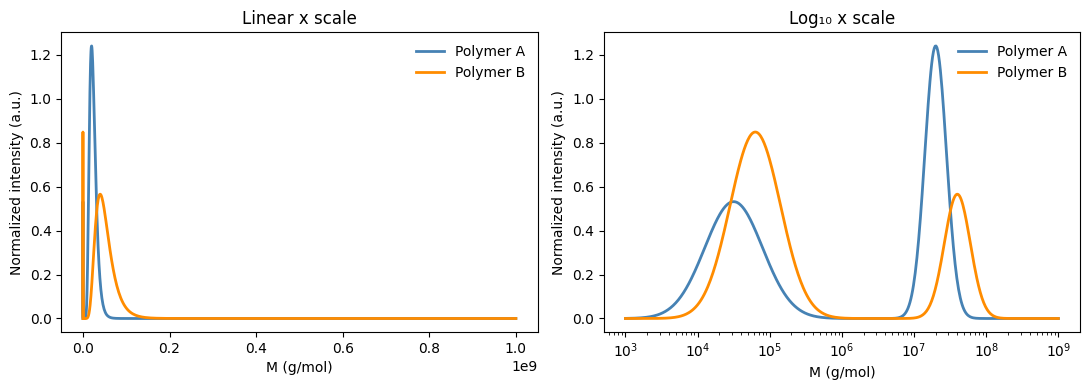

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax in axes:
    ax.plot(M, mwd_a, color='#4682B4', linewidth=2, label='Polymer A')
    ax.plot(M, mwd_b, color='#FF8C00', linewidth=2, label='Polymer B')
    ax.set_ylabel('Normalized intensity (a.u.)')
    ax.legend(frameon=False, fontsize=10)

# Left: linear x axis — the low-MW peak is crushed against the left edge
axes[0].set_xlabel('M (g/mol)')
axes[0].set_title('Linear x scale')

# Right: log10 x axis — both peaks are visible, tick labels show actual g/mol values
axes[1].set_xscale('log')
axes[1].set_xlabel('M (g/mol)')
axes[1].set_title('Log₁₀ x scale')

plt.tight_layout()
plt.show()

On the linear scale the low-MW peak at ~30,000 g/mol is invisible because the axis must stretch to accommodate the high-MW peak at ~1.5 million g/mol. On the log scale both peaks are well resolved and the tick labels read in actual g/mol units: 10³, 10⁴, 10⁵, and so on. This is exactly what GPC/SEC software produces by default. The key difference from Module 03 is that we now pass `M` (raw values in g/mol) to the plot, not `log_M`: the axis handles the transformation.

The same principle applies to any data spanning several orders of magnitude. The next example uses a reaction rate constant, where the dynamic range is even larger and a log y scale is needed instead of x.

### Rate constant over temperature

The Arrhenius equation predicts a rate constant that spans roughly six orders of magnitude between 250 K and 600 K for a typical activation energy. On a linear y scale the low-temperature region is completely unreadable; on a log scale the full behavior is visible.

In [4]:
# Arrhenius equation: k = A * exp(-Ea / (R * T))
R  = 8.314          # J / (mol K)
A  = 1e13           # pre-exponential factor (s^-1)
Ea = 80_000         # activation energy (J/mol)

T_K   = np.linspace(250, 600, 300)
k_arr = A * np.exp(-Ea / (R * T_K))

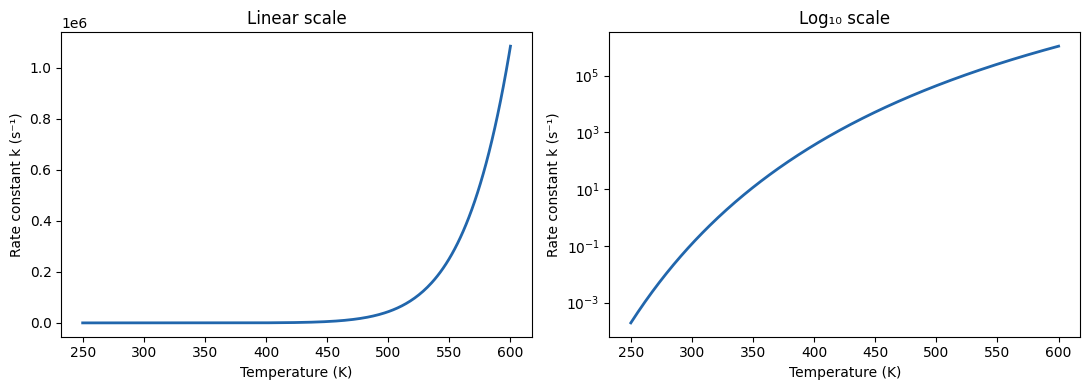

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: linear y scale
axes[0].plot(T_K, k_arr, color='#2166ac', linewidth=2)
axes[0].set_xlabel('Temperature (K)')
axes[0].set_ylabel('Rate constant k (s⁻¹)')
axes[0].set_title('Linear scale')

# Right: log10 y scale
axes[1].plot(T_K, k_arr, color='#2166ac', linewidth=2)
axes[1].set_yscale('log')
axes[1].set_xlabel('Temperature (K)')
axes[1].set_ylabel('Rate constant k (s⁻¹)')
axes[1].set_title('Log₁₀ scale')

plt.tight_layout()
plt.show()

On the linear scale, everything below about 500 K looks flat because those values are tiny compared to the maximum. On the log scale, each order of magnitude occupies the same vertical distance, and the exponential relationship appears as a curve readable across the full temperature range. `ax.set_xscale('log')` does the same thing for the x axis, as we just saw with the MWD data.

## Natural log scale

Matplotlib does not have a built-in natural log (`ln`) scale the way it has `'log'` for base 10. The practical solution is to compute `np.log(y)` before plotting and relabel the axis to make clear what is being shown. This is not a workaround so much as the honest approach: you are plotting `ln(k)` as a number, and the label should say so.

The Arrhenius equation in its linearized form is a natural case for this. Taking the natural log of both sides gives:

$$\ln(k) = \ln(A) - \frac{E_a}{R} \cdot \frac{1}{T}$$

Plotted as `ln(k)` versus `1/T`, this relationship becomes a straight line whose slope is `-Ea/R`.

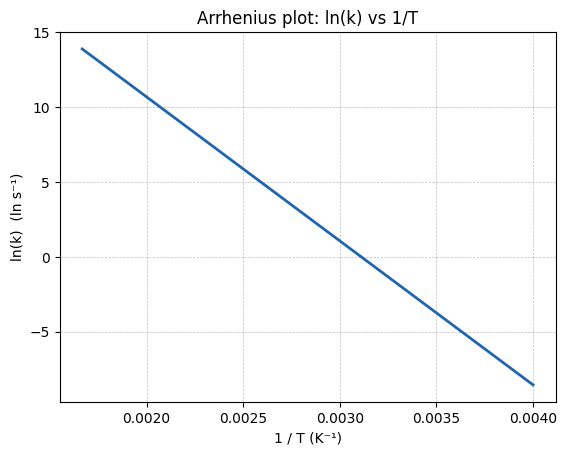

In [6]:
inv_T  = 1 / T_K          # 1/T (K^-1)
ln_k   = np.log(k_arr)    # natural log of the rate constant

fig, ax = plt.subplots()

ax.plot(inv_T, ln_k, color='#2166ac', linewidth=2)

# Label the axes clearly so the reader knows these are transformed quantities
ax.set_xlabel('1 / T (K⁻¹)')
ax.set_ylabel('ln(k)  (ln s⁻¹)')
ax.set_title('Arrhenius plot: ln(k) vs 1/T')

ax.grid(which='major', linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

plt.show()

The relationship is perfectly linear because there is no noise in the data yet. The slope of this line is `-Ea/R`, which means you can extract the activation energy from the gradient. We will do exactly that in the curve fitting section below, using noisy data.

## Symlog scale

The standard log scale cannot include zero or negative values. The symlog (symmetric log) scale handles this by applying a linear region around zero and a log scale on both sides of it. It is the right choice when your data passes through zero and has values that span several orders of magnitude on either side.

A physically relevant example is a current-voltage (I-V) sweep through a non-linear device: the current can be positive or negative, and it can span microamperes to milliamperes.

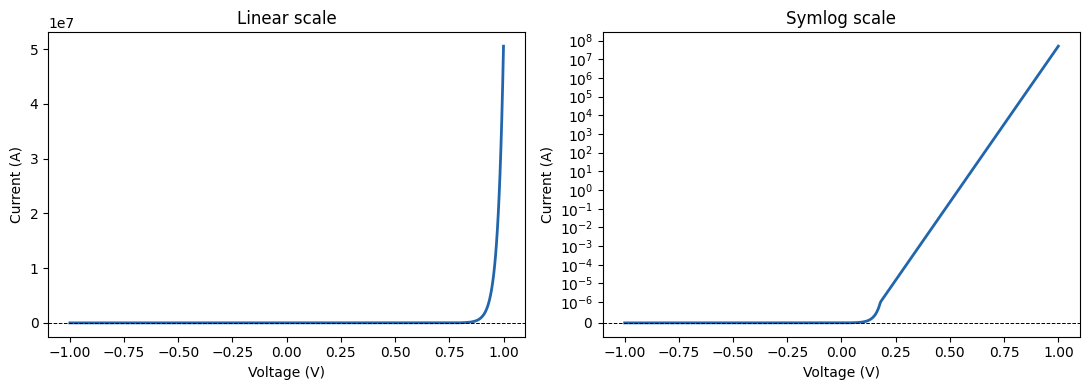

In [7]:
# Simplified diode-like I-V curve with both positive and negative current
V     = np.linspace(-1.0, 1.0, 500)
I_sat = 1e-9   # saturation current (A)
I_V   = I_sat * (np.exp(V / 0.026) - 1)  # Shockley diode equation (room temp)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: linear scale (low-current region invisible)
axes[0].plot(V, I_V, color='#2166ac', linewidth=2)
axes[0].set_xlabel('Voltage (V)')
axes[0].set_ylabel('Current (A)')
axes[0].set_title('Linear scale')
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')

# Right: symlog scale (structure on both sides of zero becomes visible)
axes[1].plot(V, I_V, color='#2166ac', linewidth=2)
axes[1].set_yscale('symlog', linthresh=1e-6)  # linear region within +/-1e-6 A
axes[1].set_xlabel('Voltage (V)')
axes[1].set_ylabel('Current (A)')
axes[1].set_title('Symlog scale')
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--')

plt.tight_layout()
plt.show()

The `linthresh` parameter defines the width of the linear region around zero. Values inside `±linthresh` are plotted linearly; values outside are plotted on a log scale. Setting `linthresh` too small makes the transition abrupt and visually jarring; setting it too large defeats the purpose. A reasonable starting point is one to two orders of magnitude below the smallest non-zero value you care about.

## Setting axis limits

`ax.set_xlim()` and `ax.set_ylim()` let you zoom in on a region of the data without modifying the data itself. This is different from filtering the data before plotting: the full dataset is still passed to Matplotlib, but the view is restricted. This matters for curve fits and reference lines, which are computed over the full range and should extend consistently even when you zoom in.

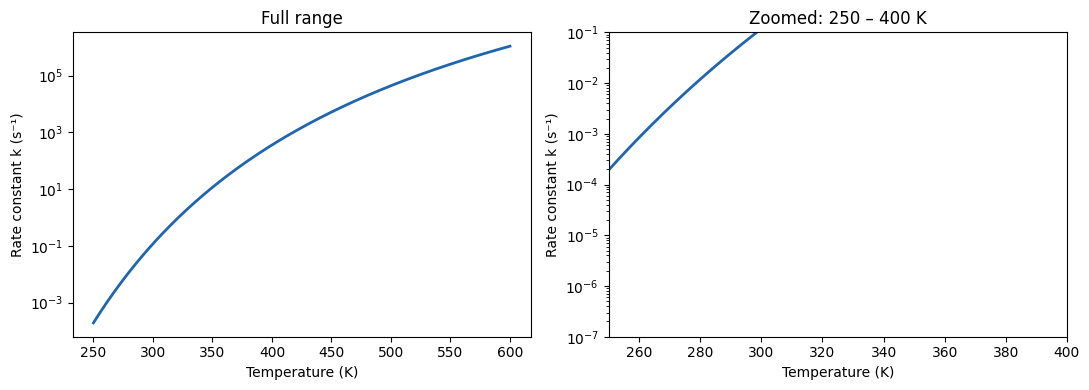

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax in axes:
    ax.plot(T_K, k_arr, color='#2166ac', linewidth=2)
    ax.set_yscale('log')
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Rate constant k (s⁻¹)')

axes[0].set_title('Full range')

# Zoom into the low-temperature region where the rate is most sensitive
axes[1].set_xlim(250, 400)
axes[1].set_ylim(1e-7, 1e-1)
axes[1].set_title('Zoomed: 250 – 400 K')

plt.tight_layout()
plt.show()

The data in both panels is identical. The right panel simply restricts the view. If you pass only one value to `set_xlim` or `set_ylim` as a tuple with `None` for one end, e.g. `ax.set_xlim(300, None)`, Matplotlib will fix one boundary and auto-scale the other.

## Horizontal and vertical reference lines

Reference lines mark thresholds, targets, or baseline values. `ax.axhline(y)` draws a horizontal line at a fixed y value across the full width of the axes; `ax.axvline(x)` draws a vertical line at a fixed x value. Both should be styled to sit visually behind the data rather than competing with it.

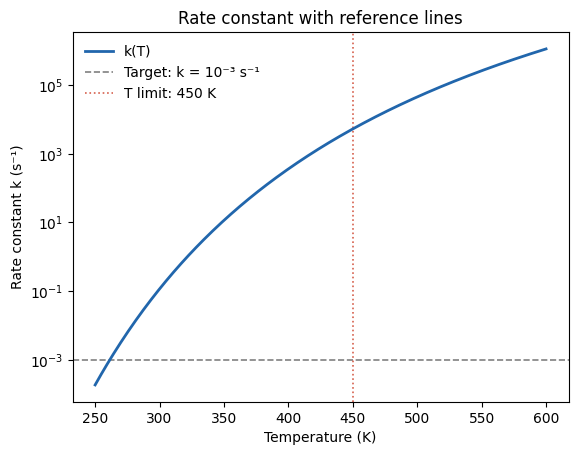

In [9]:
fig, ax = plt.subplots()

ax.plot(T_K, k_arr, color='#2166ac', linewidth=2, zorder=3, label='k(T)')
ax.set_yscale('log')

# Horizontal reference: a target rate constant of 1e-3 s^-1
ax.axhline(1e-3,
           color='grey', linewidth=1.2, linestyle='--',
           zorder=1, label='Target: k = 10⁻³ s⁻¹')

# Vertical reference: a process temperature limit of 450 K
ax.axvline(450,
           color='#d6604d', linewidth=1.2, linestyle=':',
           zorder=1, label='T limit: 450 K')

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Rate constant k (s⁻¹)')
ax.set_title('Rate constant with reference lines')
ax.legend(frameon=False, fontsize=10)

plt.show()

The `zorder` argument controls the drawing order: higher values appear in front. Setting the data line to `zorder=3` and the reference lines to `zorder=1` ensures the data is never obscured. The dashed grey horizontal line and the dotted red vertical line are visually distinct from each other and from the solid data line, so the legend is almost redundant.

## Broken axis

Occasionally a dataset has two clusters of x values separated by a wide gap that contains no data. Showing that gap in full wastes space and compresses the interesting regions. A broken axis signals to the reader that the x scale is discontinuous, without discarding any data or distorting the scale within each region.

Matplotlib has no built-in broken-axis type, but the standard implementation uses two side-by-side subplots that share a y axis. Each subplot covers one region of x. The inner spines are hidden to make the two panels look like one continuous plot, and small diagonal tick marks are drawn at the break to signal that the axis is not continuous.

The dataset here represents tensile strength measurements of a polymer composite at different filler loadings. Experiments were run at low loadings (0 to 10 wt%) and at high loadings (40 to 60 wt%), but no experiments were run in the intermediate range.

In [10]:
# Filler content (wt%) and tensile strength (MPa) — two separate experimental regions
wt_low       = np.array([0,  2,  4,  6,  8,  10])
strength_low = np.array([32, 35, 38, 40, 41, 42])

wt_high       = np.array([40, 45, 50, 55, 60])
strength_high = np.array([55, 61, 68, 72, 74])

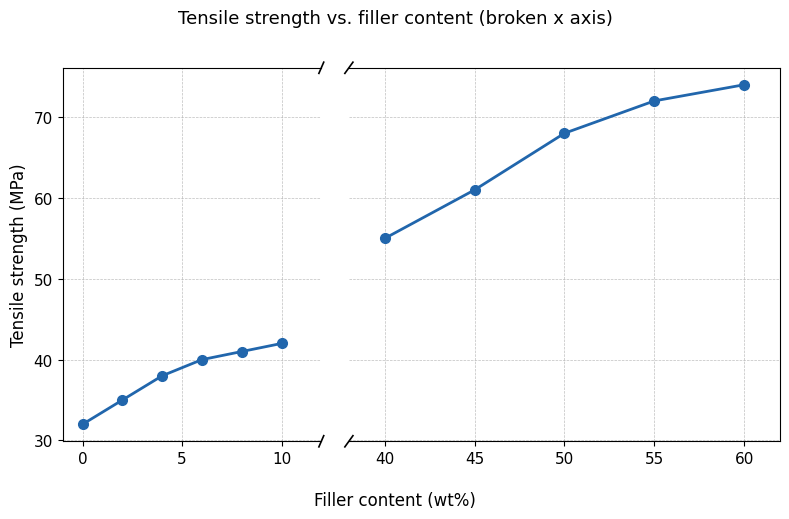

In [11]:
fig, (ax_left, ax_right) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(8, 5),
    gridspec_kw={'width_ratios': [1.2, 2]}  # wider right panel to match its larger x range
)

# ── Plot data in each panel ────────────────────────────────────────────────────
for ax, wt, strength in [
    (ax_left,  wt_low,  strength_low),
    (ax_right, wt_high, strength_high)
]:
    ax.plot(wt, strength,
            color='#2166ac', linewidth=2, marker='o', markersize=7)
    ax.grid(which='major', linestyle='--', linewidth=0.5, color='grey', alpha=0.5)
    ax.tick_params(labelsize=11)

# ── Set x limits tightly around each data cluster ─────────────────────────────
ax_left.set_xlim(-1, 12)
ax_right.set_xlim(38, 62)

# ── Hide the inner spines to merge the panels visually ────────────────────────
ax_left.spines['right'].set_visible(False)
ax_right.spines['left'].set_visible(False)
ax_right.yaxis.set_tick_params(left=False)

# ── Diagonal break markers ─────────────────────────────────────────────────────
# Each marker is a short diagonal line drawn in axes-fraction coordinates,
# crossing the inner spine at the top and bottom to signal the discontinuity.
d  = 0.015   # half-height of the diagonal in axes-fraction units
fw, fh = fig.get_size_inches()
dx = d * (fh / fw)  # correct horizontal extent for the figure aspect ratio

marker_kw = dict(color='black', linewidth=1.2, clip_on=False)

for y_pos in [0, 1]:
    # Right edge of left panel
    ax_left.plot(
        [1 - dx, 1 + dx], [y_pos - d, y_pos + d],
        transform=ax_left.transAxes, **marker_kw
    )
    # Left edge of right panel
    ax_right.plot(
        [0 - dx, 0 + dx], [y_pos - d, y_pos + d],
        transform=ax_right.transAxes, **marker_kw
    )

# ── Labels and title ──────────────────────────────────────────────────────────
fig.supxlabel('Filler content (wt%)', fontsize=12, y=0.01)
ax_left.set_ylabel('Tensile strength (MPa)', fontsize=12)
fig.suptitle('Tensile strength vs. filler content (broken x axis)', fontsize=13, y=1.01)

plt.tight_layout()
plt.subplots_adjust(wspace=0.08)  # close the gap between panels
plt.show()

A few implementation details worth noting. `sharey=True` ensures the y axis is identical in both panels, which is essential for an honest comparison: the same MPa value sits at the same height on both sides of the break. The `width_ratios` key sets the relative panel widths; matching it to the x range ratio keeps the point spacing visually similar across the break.

The diagonal markers are drawn with `transform=ax.transAxes` and `clip_on=False`. The axes-fraction coordinate system means the markers always sit at the spine edges regardless of the data range, and `clip_on=False` lets them extend slightly outside the axes box to produce the crossing-line appearance. The horizontal extent `dx` is corrected for the figure aspect ratio so the diagonals appear at a consistent angle.

One honest caution: broken axes require the reader to notice and correctly interpret the discontinuity. The diagonal markers are the conventional signal, but they can be missed. If you use a broken axis in a publication, call it out explicitly in the figure caption.

## Curve fitting
Fitting a model to experimental data is one of the most common quantitative tasks in a scientific workflow.
Think of `np.polyfit` as the "magic button" in Excel that calculates your trendline; you just tell it your data and the degree (like **2** for a curve). 
To actually see the math, `np.poly1d` takes those raw coefficients and formats them into a readable equation like $y = ax^2 + bx + c$.

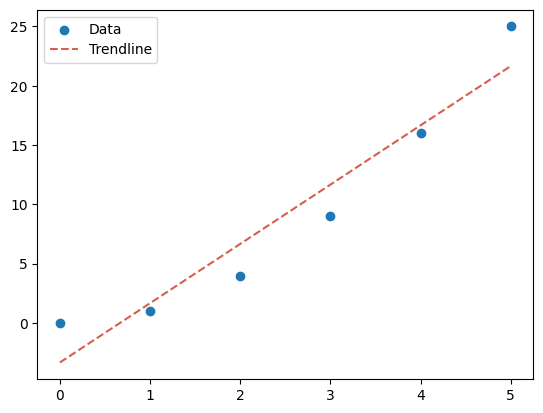

The equation is:
 
5 x - 3.333


In [12]:
x = [0, 1, 2, 3, 4, 5]
y = [0, 1, 4, 9, 16, 25]

# Fit the polynomial (change the degree from 1 to 2)
p = np.poly1d(np.polyfit(x, y, 1))

# Plotting
plt.scatter(x, y, label='Data') # Original points
plt.plot(x, p(x), linestyle='--', color='#d6604d', label='Trendline')  # Trendline
plt.legend()
plt.show()

print(f"The equation is:\n{p}")

## Curve fitting with `scipy.optimize.curve_fit`

`curve_fit` takes a Python function, an array of x values, an array of y values, and returns the best-fit parameters along with their covariance matrix, from which you can extract uncertainties.

The example uses the Arrhenius equation fitted to noisy synthetic data: realistic because the equation is genuinely used this way in chemical kinetics, and instructive because the parameters have clear physical meaning.

In [13]:
np.random.seed(42)

# Sparse experimental measurements: 20 temperature points
T_exp = np.linspace(300, 600, 20)
k_exp = A * np.exp(-Ea / (R * T_exp))

# Add multiplicative log-normal noise (realistic for rate constant measurements)
noise_factor = np.random.lognormal(mean=0, sigma=0.3, size=len(T_exp))
k_noisy = k_exp * noise_factor

Log-normal noise is appropriate here because rate constants are positive and the scatter tends to be proportional to the value rather than absolute. A fixed additive noise of ±0.1 would be negligible at high temperatures where k is large, but dominant at low temperatures where k is tiny.

In [14]:
# Define the model function: Arrhenius in terms of parameters to be fitted
# curve_fit passes x as the first argument, then the free parameters
def arrhenius(T, A_fit, Ea_fit):
    return A_fit * np.exp(-Ea_fit / (R * T))

# Initial guesses for A and Ea (should be in the right ballpark)
p0 = [1e12, 70_000]

# Run the fit
# popt: best-fit parameter values [A_fit, Ea_fit]
# pcov: covariance matrix; diagonal entries are the variances of each parameter
popt, pcov = curve_fit(arrhenius, T_exp, k_noisy, p0=p0, maxfev=10000)

A_fit, Ea_fit = popt
A_err, Ea_err = np.sqrt(np.diag(pcov))  # one standard deviation uncertainties

print(f'A  = {A_fit:.3e}  ± {A_err:.2e}  s⁻¹')
print(f'Ea = {Ea_fit/1000:.2f}  ± {Ea_err/1000:.2f}  kJ/mol')
print(f'True values:  A = {A:.2e},  Ea = {Ea/1000:.1f} kJ/mol')

A  = 3.389e+11  ± 3.45e+11  s⁻¹
Ea = 64.97  ± 4.95  kJ/mol
True values:  A = 1.00e+13,  Ea = 80.0 kJ/mol


`np.sqrt(np.diag(pcov))` extracts the standard deviations for each parameter from the covariance matrix. These are one-sigma uncertainties assuming the noise is Gaussian. With only 20 data points and significant scatter, the recovered values will not match the true values exactly, but they should be close.

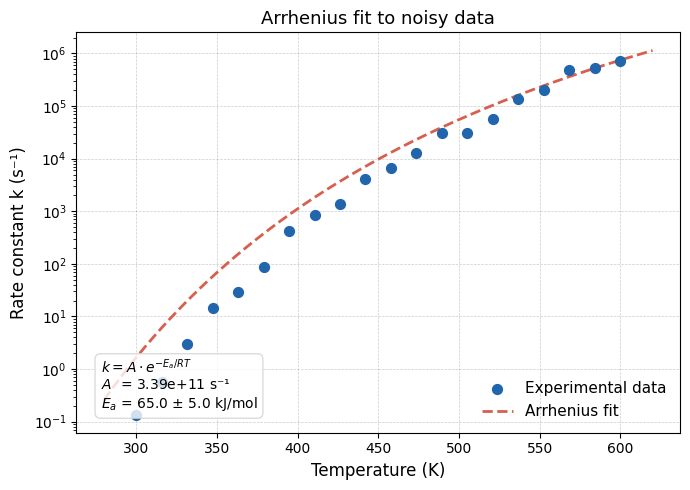

In [15]:
# Dense x array for a smooth fitted curve
T_fit_line = np.linspace(280, 620, 400)
k_fit_line = arrhenius(T_fit_line, *popt)  # unpack popt as positional arguments

fig, ax = plt.subplots(figsize=(7, 5))

# Experimental data points
ax.scatter(T_exp, k_noisy,
           color='#2166ac', s=50, zorder=3,
           label='Experimental data')

# Fitted curve
ax.plot(T_fit_line, k_fit_line,
        color='#d6604d', linewidth=2, linestyle='--',
        zorder=2, label='Arrhenius fit')

ax.set_yscale('log')
ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Rate constant k (s⁻¹)', fontsize=12)
ax.set_title('Arrhenius fit to noisy data', fontsize=13)

# Annotate the figure with the fitted parameters
fit_text = (
    f'$k = A \\cdot e^{{-E_a/RT}}$\n'
    f'$A$  = {A_fit:.2e} s⁻¹\n'
    f'$E_a$ = {Ea_fit/1000:.1f} ± {Ea_err/1000:.1f} kJ/mol'
)
ax.text(0.04, 0.05, fit_text,
        transform=ax.transAxes,    # coordinates in axes fraction (0-1), not data units
        fontsize=10,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='lightgrey', alpha=0.8))

ax.legend(loc='lower right', frameon=False, fontsize=11)
ax.grid(which='major', linestyle='--', linewidth=0.5, color='grey', alpha=0.4)

plt.tight_layout()
plt.show()

The `transform=ax.transAxes` argument to `ax.text()` changes the coordinate system from data units to axes-fraction units: `(0, 0)` is the bottom-left corner of the axes and `(1, 1)` is the top-right. This means the annotation box stays in place regardless of the axis limits, which is more robust than trying to place text at specific data coordinates. The `bbox` dictionary draws a rounded white box behind the text to keep it readable against the plot background.

## Linear fitting with `np.polyfit`

For a straight-line relationship, `np.polyfit` is a simpler alternative that does not require defining a function or providing initial guesses. It fits a polynomial of degree `deg` and returns the coefficients in descending order. For `deg=1` you get the slope and intercept.

The Arrhenius plot from earlier (ln(k) vs 1/T) is a natural linear case. Fitting it with `polyfit` gives slope `-Ea/R` and intercept `ln(A)` directly.

In [16]:
# Transform the noisy experimental data to the linearized form
inv_T_exp = 1 / T_exp
ln_k_noisy = np.log(k_noisy)

# Fit a degree-1 polynomial (straight line) to ln(k) vs 1/T
coeffs = np.polyfit(inv_T_exp, ln_k_noisy, deg=1)
slope, intercept = coeffs

Ea_linear = -slope * R           # activation energy from the slope
A_linear  = np.exp(intercept)    # pre-exponential factor from the intercept

print(f'Slope     = {slope:.1f}')
print(f'Ea (from polyfit) = {Ea_linear/1000:.2f} kJ/mol')
print(f'A  (from polyfit) = {A_linear:.3e} s⁻¹')

Slope     = -9290.7
Ea (from polyfit) = 77.24 kJ/mol
A  (from polyfit) = 4.400e+12 s⁻¹


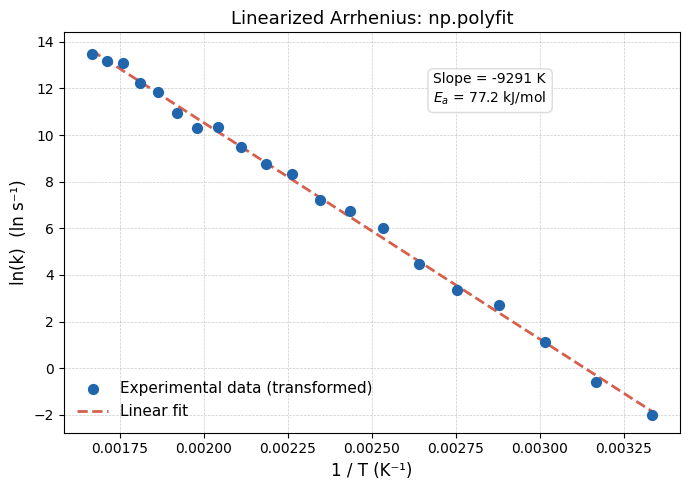

In [17]:
# Generate the fitted line for plotting
inv_T_line = np.linspace(inv_T_exp.min(), inv_T_exp.max(), 300)
ln_k_line  = np.polyval(coeffs, inv_T_line)  # evaluate polynomial at each point

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(inv_T_exp, ln_k_noisy,
           color='#2166ac', s=50, zorder=3,
           label='Experimental data (transformed)')

ax.plot(inv_T_line, ln_k_line,
        color='#d6604d', linewidth=2, linestyle='--',
        zorder=2, label='Linear fit')

# Annotate with the recovered parameters
lin_text = (
    f'Slope = {slope:.0f} K\n'
    f'$E_a$ = {Ea_linear/1000:.1f} kJ/mol'
)
ax.text(0.60, 0.90, lin_text,
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='lightgrey', alpha=0.8))

ax.set_xlabel('1 / T (K⁻¹)', fontsize=12)
ax.set_ylabel('ln(k)  (ln s⁻¹)', fontsize=12)
ax.set_title('Linearized Arrhenius: np.polyfit', fontsize=13)
ax.legend(frameon=False, fontsize=11)
ax.grid(which='major', linestyle='--', linewidth=0.5, color='grey', alpha=0.4)

plt.tight_layout()
plt.show()

`np.polyval(coeffs, x)` evaluates the fitted polynomial at any x values, which is how the smooth fitted line is generated. The `polyfit` approach is fast and requires no initial guesses, but it has two limitations worth knowing: it does not return parameter uncertainties directly (you need `np.polyfit` with `cov=True` for that), and it only works for relationships that can be linearized algebraically. When the model cannot be linearized, `curve_fit` is the right tool.